# Import packages

In [1]:
import re
import json
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import gensim.downloader as api


import warnings

warnings.filterwarnings(
    "ignore",
    category=FutureWarning
)

## Import the Loughran-McDonald dictionary 
I will also refer the Loughran-McDonald dictionary as financial dictionary

In [2]:
# Load the Loughran-McDonald dictionary
lm_df = pd.read_csv('data_files/Loughran-McDonald_MasterDictionary_1993-2025.csv')

# Ensure the 'Word' column is string and uppercase (LM dictionary defaults to uppercase)
lm_df['Word'] = lm_df['Word'].astype(str).str.upper()

# CBO Sentiment Expansion Pipeline: Loughran-McDonald Uncertainty Terms

## Project Overview
This notebook measures narrative uncertainty across historical CBO report text blocks. It expands upon the  financial sentiment terms established by Loughran and McDonald (LM) by using context words to shift towards a fiscal and budgetary theme.

### Current Approach
The notebook combines 297 base terms from the Loughran-McDonald (LM) uncertainty dictionary with context keywords to discover contextually relevant synonyms in vector space. Each paragraph is then scored against this combined list of words using a weighted density calculation. For subsequent correlation analyses against fiscal forecasts, CBO projection errors are converted to absolute values ($|\text{Forecast Error}|$).

---

## Pipeline Architecture

The pipeline processes data along two main tracks—**Vector Engine Setup** and **Word Expansion**—before scoring paragraphs and exporting results:

### 1. Vector Engine & Context Setup (Sections 1, 2 & 2b)
* **Word2Vec Engine Loading:** Loads the pre-trained `word2vec-google-news-300` vector model.
* **Context Anchoring (`build_context_vec`):** Constructs a baseline reference vector by averaging coordinates for core budget terms (*spending*, *outlays*, *federal*, *congress*, *budget*).

### 2. Expanded Word Track (Section 3)
* **Financial Words Processing:** Ingests the core 297 Loughran-McDonald uncertainty words.
* **Vector Extraction (`get_vec` / `unit_vec`):** Maps each LM word into 300-dimensional space and normalizes it to unit length.
* **Weighted Vector Nudging:** Blends each word vector with the context vector to anchor search within fiscal context.
* **Neighbor Search (`similar_by_vector`):** Queries the top 200 nearest vector neighbors for each nudged term.
* **High-Hygiene Screening (`keep_synonym_candidate`):** Filters candidate words using structural checks and proper-noun checks to eliminate geographic, political, or formatting noise.
* **Vocabulary Consolidation (`get_dynamic_vocabulary`):** Merges the original 297 LM base terms with approximately 1,000 validated Word2Vec synonyms.

### 3. Scoring & Execution (Sections 4 & 5)
* **Weighted Text Scoring (`compute_contextual_uncertainty_score`):** Scans paragraph text and computes a weighted density score, assigning a weight of **1.00** to direct LM terms and **0.35** to expanded Word2Vec synonyms, then dividing by the length of each paragraph.
* **Output & Export:** Saves the consolidated vocabulary to `data_files/lexicon.json` and exports paragraph-level uncertainty scores, `data_files/chunked_paragraphs_with_embeddings_uncert.csv` for statistical analysis.

---

## Core Methodology

### 1. Vector Space Nudging Formula
To ground standard financial uncertainty words within fiscal vocabulary, each word vector ($\vec{V}_{\text{word}}$) is added with the budgetary context vector ($\vec{V}_{\text{context}}$):

$$\vec{V}_{\text{final}} = 4.0 \cdot \text{unit}(\vec{V}_{\text{word}}) + 1.0 \cdot \text{unit}(\vec{V}_{\text{context}})$$

This directional shift forces the model to discover uncertainty synonyms that appear specifically within federal budget context rather than general commercial or corporate news.

### 2. Proper-Noun Filtering Heuristic
To prevent geographic or institutional clutter during nearest-neighbor retrieval (such as pulling agency names, political figures, or locations), candidate tokens ($T$) are evaluated through a casing filter prior to lowercasing:

$$\text{Is Proper Noun} = \text{IsUpper}(T_0) \land (T_{\text{lower}} \notin \text{Standard Dictionary})$$

Any token whose original model string begins with an uppercase letter and does not match a standard English dictionary word is discarded.

In [23]:
# Load your matched data file from the previous notebook steps.
chunked_pg_w_embed = pd.read_csv("data_files/chunked_paragraphs_with_embeddings.csv")

# =====================================================================
# 0. CONFIGURATION MANAGEMENT
# =====================================================================
# Core settings that control how our AI searches for synonyms and scores text.

# Domain Anchors: These words represent the "flavor" of text we want to target.
# They nudge the AI to look specifically for public finance and budget terms.
SYNONYM_CONTEXT_TERMS = ["spending", "outlays", "federal", "congress", "budget"]

# Nudging Ratio (4:1): When looking for synonyms, we want them to stay mostly true 
# to the core uncertainty meaning (weight = 4.0), but slightly blended with our 
# public finance vocabulary context (weight = 1.0).
SYNONYM_LABEL_WEIGHT = 4.0
SYNONYM_CONTEXT_WEIGHT = 1.0

# Expansion Boundaries
N_GLOBAL_W2V_SYNONYMS = 1000   # Stop collecting once we reach the top 1,000 best synonyms overall
TOPN_PER_LM_WORD_SEARCH = 200  # For each core word, pull its top 200 closest neighbors
MAX_CONTRIB_PER_LM_WORD = 8    # Don't use more than 8 synonyms of any words

# Downstream Text Scoring Weights
WEIGHT_LM = 1.0   # True dictionary words get full point weight (1.0)
WEIGHT_W2V = 0.35 # Discovered AI synonyms get partial point weight (0.35)

# File and Regeneration Boundaries
LEXICON_JSON = Path("data_files/lm_uncertainty_lexicon_297_plus_1000_w2v.json")
REGENERATE_LEXICON = True # True = clear out old data and rebuild the vocabulary dictionary from scratch

# Blacklists & Content Filters: Keeping junk words from sneaking into our dictionary.
EXCLUDE_LM_FROM_EXPANSION = {"MAY", "MIGHT", "CAN", "COULD", "WOULD", "SHOULD", "WILL"}
FORBIDDEN = {t.lower() for t in SYNONYM_CONTEXT_TERMS} | {
    "spend", "spending", "outlay", "outlays", "budget", "federal", "congress",
    "program", "programs", "policy", "policies", "year", "years", "percent", 
    "billion", "million",
}
MIN_LEN = 4                   # Skip short words that are less than 4 letters long
ALLOW_UNDERSCORE_PHRASES = False # Set to False to reject compound tokens like "fiscal_deficit"


# =====================================================================
# 1. MODEL INGESTION (Loading the AI Space)
# =====================================================================
print("🔄 Loading pre-trained Word2Vec embeddings (word2vec-google-news-300)...")
# Downloads and spins up Google's massive pre-trained news model.
# This model mapped millions of English words into a 300-dimensional coordinate map
# based on how closely they appeared next to one another in actual news text.
w2v_model = api.load("word2vec-google-news-300")
print("✅ Word2Vec embeddings space mounted successfully.")


# =====================================================================
# 2. VECTOR ARITHMETIC CORE FUNCTIONS (The Coordinate Math)
# =====================================================================
def unit_vec(v):
    """
    Takes a 300-dimensional array and normalizes its geometric length to exactly 1.0.
    """
    v = np.asarray(v, dtype=np.float32)
    n = np.linalg.norm(v)
    return v if n == 0 else v / n


def get_vec(token: str, model):
    """
    Looks up a word in the 300-dimensional AI map.
    """
    for t in (token, token.lower(), token.title(), token.upper()):
        if t in model:
            return model[t].astype(np.float32)
    return None


def build_context_vec(model):
    """
    Calculates the exact average, shared center point of our 5 background context words.
    """
    vecs = []
    for t in SYNONYM_CONTEXT_TERMS:
        v = get_vec(t, model)
        if v is not None:
            vecs.append(v)
    if not vecs:
        return None
    return np.mean(np.vstack(vecs), axis=0).astype(np.float32)


# Build and verify the background anchor space coordinate
CONTEXT_VEC = build_context_vec(w2v_model)
if CONTEXT_VEC is None:
    raise ValueError("None of the SYNONYM_CONTEXT_TERMS exist in the Word2Vec vocabulary.")


def add_context_influence_to_vector(v):
    """
    Blends a core word's location with our public finance center point using a 4:1 ratio.
    
    Explanation:
    If you look up the word "UNSETTLED", its natural neighbors might be "divorced" or "windy". 
    By shifting its position slightly toward our context anchor vector (budgetary prose), 
    we pull its coordinate into a new neighborhood where its closest neighbors become 
    fiscal terms like "unresolved", "fluid", or "precarious".
    """
    combined = (
        SYNONYM_LABEL_WEIGHT * unit_vec(v)
        + SYNONYM_CONTEXT_WEIGHT * unit_vec(CONTEXT_VEC)
    )
    return unit_vec(combined).astype(np.float32)


# =====================================================================
# 2b. DOMAIN-SPECIFIC FILTER HYGIENE (The Safety Guardrails)
# =====================================================================
def looks_like_proper_noun(token: str, model) -> bool:
    """
    An automated heuristic rule designed to identify and catch proper nouns.
    
    Explanation:
    When doing massive keyword searches, the AI can get distracted by specific names of 
    people, countries, or space missions that happen to be linked to volatile events. This rule 
    checks if a word is capitalized but its lowercase version doesn't exist in standard text. 
    If true, it marks it as a proper noun so we can filter out noisy clutter.
    """
    if not token:
        return True
    if token[0].isupper() and (token.lower() not in model):
        return True
    return False


def keep_synonym_candidate(cand: str, base_lm_set_lower: set, model) -> bool:
    """
    A validation gateway that enforces structural filters against candidate words.
    
    Explanation:
    This function acts as a high-hygiene screen. It filters out numbers, words that are too short, 
    stray layout punctuation lines, words already present in our base dictionary, and terms 
    on our configuration blacklists to keep our vocabulary purely focused on uncertainty.
    """
    if not isinstance(cand, str) or not cand:
        return False

    # Execute proper noun filter prior to executing standard case transformations
    if looks_like_proper_noun(cand, model):
        return False

    if (not ALLOW_UNDERSCORE_PHRASES) and ("_" in cand):
        return False

    if ALLOW_UNDERSCORE_PHRASES:
        if not re.fullmatch(r"[A-Za-z_]+", cand):
            return False
    else:
        if not re.fullmatch(r"[A-Za-z]+", cand):
            return False

    cl = cand.lower()
    if len(cl) < MIN_LEN:
        return False
    if cl in base_lm_set_lower:
        return False
    if cl in FORBIDDEN:
        return False

    return True


# =====================================================================
# 3. GLOBAL LEXICON SYNTHESIS ENGINE (Building the Dictionary)
# =====================================================================
# Extract every core word from the Loughran-McDonald list that signals uncertainty
base_uncertain_words = set([w.upper() for w in lm_df[lm_df["Uncertainty"] > 0]["Word"]])
base_lm_set_lower = {w.lower() for w in base_uncertain_words}


def build_or_load_global_lexicon(model):
    """
    Coordinates the master dictionary expansion track.
    
    Explanation:
    If a saved dictionary file already exists on your disk and regeneration is turned off, 
    it reads it instantly. Otherwise, it loops over all base uncertainty words, projects them 
    into our context-nudged vector space, collects their top clean synonyms, truncates the list 
    to the best 1,000 expressions, and writes the completed package out as a master JSON file.
    """
    if LEXICON_JSON.exists() and (not REGENERATE_LEXICON):
        lex = json.loads(LEXICON_JSON.read_text(encoding="utf-8"))
        lm_words = set(lex["lm_words"])
        w2v_syns = set(lex["w2v_synonyms"])
        return lm_words, w2v_syns, lex

    cand_best = {}  # Map tracking: cand_lower -> {"score": float, "source": lm_word}
    lm_words_sorted = sorted(base_uncertain_words)

    for lm_word in lm_words_sorted:
        if lm_word in EXCLUDE_LM_FROM_EXPANSION:
            continue

        v = get_vec(lm_word, model)
        if v is None:
            continue

        # Shift the word's location toward public finance and gather 200 neighbors
        qv = add_context_influence_to_vector(v)
        nbrs = model.similar_by_vector(qv, topn=TOPN_PER_LM_WORD_SEARCH)

        contributed = 0
        for cand, score in nbrs:
            if contributed >= MAX_CONTRIB_PER_LM_WORD:
                break
            if not keep_synonym_candidate(cand, base_lm_set_lower, model):
                continue

            cl = cand.lower()
            prev = cand_best.get(cl)
            if (prev is None) or (score > prev["score"]):
                cand_best[cl] = {"score": float(score), "source": lm_word}

            contributed += 1

    # Keep only the top 1,000 unique synonyms with the absolute highest similarity scores
    top = sorted(cand_best.items(), key=lambda kv: kv[1]["score"], reverse=True)[:N_GLOBAL_W2V_SYNONYMS]
    w2v_synonyms = [w for w, meta in top]

    # Package everything together into a neat output nested dictionary structure
    payload = {
        "lm_words": sorted(base_uncertain_words),
        "w2v_synonyms": w2v_synonyms,
        "metadata": {
            "model": "word2vec-google-news-300",
            "context_terms": SYNONYM_CONTEXT_TERMS,
            "label_weight_for_query": SYNONYM_LABEL_WEIGHT,
            "context_weight_for_query": SYNONYM_CONTEXT_WEIGHT,
            "n_global_w2v_synonyms": N_GLOBAL_W2V_SYNONYMS,
            "topn_per_lm_word_search": TOPN_PER_LM_WORD_SEARCH,
            "max_contrib_per_lm_word": MAX_CONTRIB_PER_LM_WORD,
            "min_len": MIN_LEN,
            "allow_underscore_phrases": ALLOW_UNDERSCORE_PHRASES,
            "excluded_lm_from_expansion": sorted(EXCLUDE_LM_FROM_EXPANSION),
            "recommended_scoring_weights": {"lm": WEIGHT_LM, "w2v": WEIGHT_W2V},
            "proper_noun_filter": "reject token if Capitalized and lowercase not in model vocab",
        },
        "audit_w2v_synonyms": {w: cand_best[w] for w in w2v_synonyms if w in cand_best},
    }

    # Create the directory folders if they are missing, and save the lexicon to disk
    LEXICON_JSON.parent.mkdir(parents=True, exist_ok=True)
    LEXICON_JSON.write_text(json.dumps(payload, indent=2), encoding="utf-8")
    return set(payload["lm_words"]), set(payload["w2v_synonyms"]), payload


# Memory map tracking dictionary to store our cache
subcategory_expanded_cache = {}


def get_dynamic_vocabulary(subcategory, model, top_n=15):
    """
    Manages lookups to keep our script running lightning-fast across 20,000 rows.
    
    Explanation:
    Instead of recalculating or reloading our 1,297-word dictionary from scratch for every single 
    paragraph row in your dataset, it builds it once on the very first row, saves it to memory under 
    a shared cache key, and instantly serves it to the remaining 20,320 rows.
    """
    cache_key = "__GLOBAL_LM_PLUS_W2V__"
    if cache_key in subcategory_expanded_cache:
        return subcategory_expanded_cache[cache_key]

    lm_words, w2v_syns, meta = build_or_load_global_lexicon(model)
    vocab = {
        "lm_words": set(w.upper() for w in lm_words),
        "w2v_synonyms": set(w.upper() for w in w2v_syns),
        "meta": meta,
    }
    subcategory_expanded_cache[cache_key] = vocab
    return vocab


# =====================================================================
# 4. WEIGHTED SCORING PIPELINE (Grading the Text Density)
# =====================================================================
def compute_contextual_uncertainty_score(row, model, top_n=15):
    """
    Calculates the final uncertainty density score for an individual paragraph text chunk.
    
    Why this matters to a general audience:
    1. It strips out numbers and symbols to isolate pure English words.
    2. It tallies up points: if a word is a formal dictionary term, it receives 1.0 point. 
       If it is an AI-discovered public finance synonym, it receives 0.35 points.
    3. It divides the total score by the paragraph's overall word length. This normalizes 
       the score so that a 300-word paragraph and a 30-word paragraph can be compared fairly.
    """
    paragraph_text = row["text"]
    if not isinstance(paragraph_text, str) or not paragraph_text.strip():
        return 0.0

    # Isolate individual alphabetical words using strict boundary parameters (\b)
    words = re.findall(r"\b[A-Za-z]+\b", paragraph_text.upper())
    total_words = len(words)
    if total_words == 0:
        return 0.0

    vocab = get_dynamic_vocabulary(row.get("subcategory", ""), model, top_n=top_n)
    lm_set = vocab["lm_words"]
    syn_set = vocab["w2v_synonyms"]

    score = 0.0
    for w in words:
        if w in lm_set:
            score += WEIGHT_LM
        elif w in syn_set:
            score += WEIGHT_W2V

    return score / total_words


# =====================================================================
# 5. EXECUTION & REPORT GENERATION
# =====================================================================
print("\n🔎 Scoring narrative elements inside full filtered document dataframe...")

# Clean up our dataframe by dropping empty classification targets, creating a strict isolated matrix copy
tracking_columns = ["match_method", "matched_phrase", "category", "subcategory", "component"]
chunked_pg_w_embed_uncert = chunked_pg_w_embed.dropna(subset=tracking_columns).copy()

# Apply our scoring function across all 20,321 rows using active row mapping (axis=1)
chunked_pg_w_embed_uncert["contextual_uncertainty_score"] = chunked_pg_w_embed_uncert.apply(
    compute_contextual_uncertainty_score,
    axis=1,
    args=(w2v_model,),
    top_n=15,
)

# Render clean final verification execution summary table console printout dashboard
print("\n" + "="*65)
print("               UNCERTAINTY PIPELINE RUN REPORT                 ")
print("="*65)
print(f"  • Total Subcategories Cached   : {len(subcategory_expanded_cache)}")
print(f"  • Rows Evaluated Matrix Length : {len(chunked_pg_w_embed_uncert):,}")
print(f"  • Master Dictionary File Path  : {LEXICON_JSON}")
print("-" * 65)
print("📈 HIGHEST UNCERTAINTY DENSITY SAMPLE ROWS RECORDED:")
print("-" * 65)

# Isolate and truncate the top 4 highest-scoring records to verify our matching mechanics
df_sorted_sample = chunked_pg_w_embed_uncert.sort_values(
    by="contextual_uncertainty_score", ascending=False
).head(4)

for rank, (_, row) in enumerate(df_sorted_sample.iterrows(), 1):
    trunc_txt = row['text'][:55].strip() + "..." if len(row['text']) > 55 else row['text']
    print(f"   {rank}. [{row['subcategory']}] (Score: {row['contextual_uncertainty_score']:.4f}) → \"{trunc_txt}\"")

print("="*65 + "\nPipeline execution complete.")

🔄 Loading pre-trained Word2Vec embeddings (word2vec-google-news-300)...
✅ Word2Vec embeddings space mounted successfully.

🔎 Scoring narrative elements inside full filtered document dataframe...

               UNCERTAINTY PIPELINE RUN REPORT                 
  • Total Subcategories Cached   : 1
  • Rows Evaluated Matrix Length : 20,321
  • Master Dictionary File Path  : data_files\lm_uncertainty_lexicon_297_plus_1000_w2v.json
-----------------------------------------------------------------
📈 HIGHEST UNCERTAINTY DENSITY SAMPLE ROWS RECORDED:
-----------------------------------------------------------------
   1. [Social Security] (Score: 0.1727) → "CHAPTER SIX THE LONG-TERM BUDGET OUTLOOK 107 Table 6-2...."
   2. [Other Mandatory] (Score: 0.1629) → "The current business cycle has been unusual and is like..."
   3. [Social Security] (Score: 0.1612) → "Uncertainty of CBO’s Projections The budgetary and econ..."
   4. [Other Mandatory] (Score: 0.1563) → "Uncertainty of Budgetary Outcomes

# CBO Narrative Analysis: Statistical Distribution & Summary Diagnostics

## Section Overview
This section provides a simple diagnostic tool to look at how our uncertainty scores are distributed. It calculates global summary statistics, splits those numbers up by official subcategory, and renders a side-by-side plot to show us how different federal programs vary in their reporting tone.

=== GLOBAL DESCRIPTIVE STATISTICS ===
count    20321.000000
mean         0.022695
std          0.018141
min          0.000000
25%          0.010194
50%          0.019811
75%          0.031111
max          0.172727
Name: contextual_uncertainty_score, dtype: float64


=== DESCRIPTIVE STATISTICS BY SUBCATEGORY ===
                           count      mean       std  min       25%       50%  \
subcategory                                                                     
Defense Discretionary     1774.0  0.022888  0.018314  0.0  0.010208  0.020000   
Medicaid                   502.0  0.019669  0.017825  0.0  0.005932  0.015909   
Medicare                  1211.0  0.018956  0.016500  0.0  0.007292  0.016471   
Net Interest              5435.0  0.022602  0.018125  0.0  0.010294  0.020000   
Nondefense Discretionary   893.0  0.027118  0.017397  0.0  0.014583  0.024419   
Other Mandatory           1843.0  0.027728  0.021808  0.0  0.013052  0.024460   
Social Security           1907.0  0.014

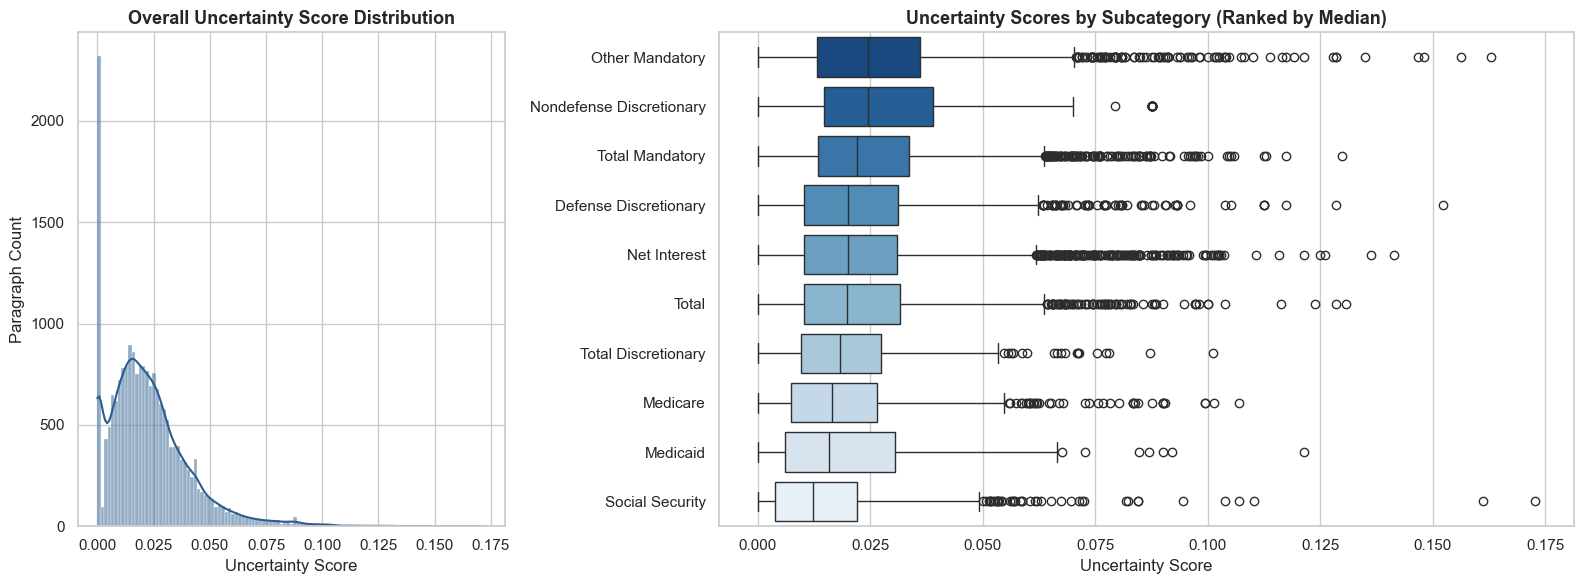

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# =====================================================================
# 0. VISUALIZATION ENVIRONMENT CONFIGURATION
# =====================================================================
# Set a clean corporate grid aesthetic for the data graphics
sns.set_theme(style="whitegrid")

# --- 1. Define your uncertainty column name ---
score_col = 'contextual_uncertainty_score' 


# =====================================================================
# 1. DESCRIPTIVE STATISTICS GENERATION ENGINE
# =====================================================================
print("=== GLOBAL DESCRIPTIVE STATISTICS ===")
print(chunked_pg_w_embed_uncert[score_col].describe())
print("\n" + "="*40 + "\n")

print("=== DESCRIPTIVE STATISTICS BY SUBCATEGORY ===")
sub_stats = chunked_pg_w_embed_uncert.groupby('subcategory')[score_col].describe()
print(sub_stats)


# =====================================================================
# 2. DATA VISUALIZATION CANVAS DEPLOYMENT
# =====================================================================
# Set up a side-by-side subplot canvas using the predefined width proportions
fig, axes = plt.subplots(1, 2, figsize=(16, 6), gridspec_kw={'width_ratios': [1, 2]})

# --- Left Plot: Global Distribution (Histogram + KDE) ---
sns.histplot(data=chunked_pg_w_embed_uncert, x=score_col, kde=True, ax=axes[0], color='#2b5c8f')
axes[0].set_title('Overall Uncertainty Score Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Uncertainty Score')
axes[0].set_ylabel('Paragraph Count')

# --- Right Plot: Distribution by Subcategory (Boxplot Matrix) ---
# Dynamically sort categories by their median value to clarify cross-program ranking
group_order = chunked_pg_w_embed_uncert.groupby('subcategory')[score_col].median().sort_values(ascending=False).index

sns.boxplot(
    data=chunked_pg_w_embed_uncert, 
    y='subcategory', 
    x=score_col, 
    ax=axes[1], 
    order=group_order,
    palette='Blues_r'
)
axes[1].set_title('Uncertainty Scores by Subcategory (Ranked by Median)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Uncertainty Score')
axes[1].set_ylabel('')  # Y-label text is clearly implied by categorical text values

# Optimize whitespace parameters and project canvas
plt.tight_layout()
plt.show()

In [27]:
# export chunked_pg_w_embed with uncertainty score
chunked_pg_w_embed_uncert.to_csv("data_files/chunked_paragraphs_with_embeddings_uncert.csv", index=False)